# **POTENTIAL FLOW**


## *Imports*


In [1]:
import numpy as np
from model_flow import uniform_complex_potential, source_complex_potential, source_complex_velocity, vortex_complex_potential, vortex_complex_velocity, dipole_complex_potential, dipole_complex_velocity
from plotting_flow import plot_streamlines_and_equipotentials, plot_cylinder_flow, plot_cylinder_pressure_distribution, plot_circulating_cylinder_flow
from render_flow import render_lifting_cylinder

## **Conventions and governing equations**


This project discusses a potential flow moving around a cylinder in 2-dimensional space, with no circulation at first. Consider a domain $D \subset \mathbb{R}^2$ which is 'sufficiently nice' (see multivariable analysis, open, connected, unbounded amongst potentially more), and a flow $\mathbf{u}: D \to \mathbb{R}^2$ with $\mathbf{u} = (u, v)$. We assume this flow is both incompressible and irrotational, that is:
$$
\nabla\cdot\mathbf{u}=0, \qquad \nabla\times\mathbf{u}=\mathbf{0}
$$

Also notice the following. Let $\phi \in C^{2}(D)$ (twice continously differentiable on our domain), then $\nabla \phi$ exists, and so does $\nabla \times (\nabla \phi)$. For any choice of $\phi$, $\nabla \times (\nabla \phi)=\mathbf{0}$, so choosing $\phi$ such that $\mathbf{u} = \nabla \phi$ is what we call a potential flow. $\phi$ is called the potential for $\mathbf{u}$. Since our cylinder has no circulation, $\phi$ exists globally and is defined just up to constant. Then, for $\mathbf{u} = (u, v)$:
$$
0 = \nabla\cdot\mathbf{u} = \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y}
$$
So defining $\psi \in C^{2}(D)$ such that $\mathbf{u} = \left(\frac{\partial \psi}{\partial y}, - \frac{\partial \psi}{\partial x}\right)$, we get:
$$
\nabla\cdot\mathbf{u} = \frac{\partial}{\partial x}\left(\frac{\partial \psi}{\partial y}\right) + \frac{\partial}{\partial y}\left(- \frac{\partial \psi}{\partial x}\right) = 0
$$
since $\psi \in C^{2}(D)$ allows interchanging of partial derivatives due to their continuity. Such $\psi$ is called a stream function for $\mathbf{u}$. Notice by comparing expressions for $u, v$:
$$
\frac{\partial \psi}{\partial y}=\frac{\partial \phi}{\partial x}\qquad -\frac{\partial \psi}{\partial x}=\frac{\partial \phi}{\partial y}
$$
If you're familiar with complex analysis, you will realise these are the Cauchy-Riemann equations. We will return to these very shortly.


By inputting our new potential $\mathbf{u} = \nabla \phi$ into the incompressibility equation, we get:
$$
0 = \nabla\cdot\mathbf{u} = \nabla\cdot(\nabla \phi) = \nabla^2\phi
$$
meaning that $\phi$ must be a solution to the Laplace equation on our domain. The same applies to $\psi$. Since $\mathbf{u}$ is irrotational, we get: 
$$
0 = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y} = - \frac{\partial^2 \psi}{\partial x^2} - \frac{\partial^2 \psi}{\partial y^2} = -\nabla^2 \psi
$$
Such equation requires necessary boundary conditions for a well-posed solution. Here is where we impose the 'no-penetration' boundary condition, given by:
$$
\mathbf{u} \cdot \hat{\mathbf{n}} = 0  \quad \text{on } \partial D
$$
where $\hat{\mathbf{n}}$ is the outward-pointing unit normal to our domain D. Intuitively, this says that the fluid cannot 'go through' our surface. There is also another boundary condition, known as the 'far-field' condition, where we impose:
$$
\mathbf{u}(x, y) \to U \mathbf{e}_{x} \qquad \text{as } r:=\sqrt{x^2+y^2} \to \infty
$$
where $U>0$ is the given 'far-field' speed.

## **Complex potential**


The complex potential is defined as:

$$
w(z)= \phi(x,y)+ i \psi(x,y)
$$

This function is analytic since $\phi, \psi$ are continuously differentiable as maps on $\mathbb{R}^2$ and satisfy the Cauchy-Riemann equations. Hence we can differentiate in each direction, and they all must be equal (elementary complex analysis), so differentiating in the x-direction:
$$
\frac{dw}{dz} = \frac{\partial \phi}{\partial x} + i \frac{\partial \psi}{\partial x} = u - iv
$$

Before discussing some examples, we briefly define some visual properties of the potential and stream functions. A surface $S \subset \mathbb{R}^2$ is an equipotential surface if $\exists c \in \mathbb{R}$ such that $\phi = c$ on S. Notice for the stream function:
$$
\nabla \psi \cdot \mathbf{u} = \frac{\partial \psi}{\partial x} u + \frac{\partial \psi}{\partial y} v = -vu + uv = 0
$$
Hence the stream function doesn't change in the direction of streamlines. Equivalently, $\psi$ is constant along streamlines, and the streamlines of our flow are contours of constant $\psi$. Comparing the two, notice:
$$
\nabla \psi \cdot \nabla \phi = \nabla \psi \cdot \mathbf{u} =0
$$
Meaning that equipotential surfaces are orthogonal to streamlines of our flow.

## **Elementary flows**


We now discuss some elementary flows. For each one, start with the complex potential, derive the flow, the potential and the stream function, before plotting.

### Uniform flow

Consider a uniform flow with speed $U>0$ in the positive x-direction, making an angle $\beta\in\mathbb{R}$ with the x-axis. Then, the complex potential for this flow is given by:
$$
w(z) = U e^{-i\beta}z
$$
Then differentiating w.r.t z, and applying the relationship above, we get:
$$
u -iv = \frac{dw}{dz} = U e^{-i\beta}
$$
Comparing real and imaginary parts, (and using that sin is odd) we get:
$$
(u, v) = (U\cos{\beta}, U\sin{\beta})
$$
Then, 
$$
u = \frac{\partial \phi}{\partial x} = \frac{\partial \psi}{\partial y}, \qquad v = \frac{\partial \phi}{\partial y} = -\frac{\partial \psi}{\partial x}
$$
Then integrating in both variables:
$$
\phi(x, y) = U\left(x\cos{\beta} + y\sin{\beta}\right), \qquad \psi(x, y) = U\left(y\cos{\beta} - x\sin{\beta}\right)
$$
Where constants of integration are set to zero as both functions are only defined up to constant. The streamlines of our flow are contours where the stream function is constant. Identically for the equipotential surfaces, so for $C_1, C_2\in\mathbb{R}$, the contours satisfy:
$$
x\cos{\beta} + y\sin{\beta} = \frac{C_1}{U}, \qquad y\cos{\beta} - x\sin{\beta} = \frac{C_2}{U}
$$
By the work we have done, we expect these contours to be orthogonal to each other. They are plotted below:

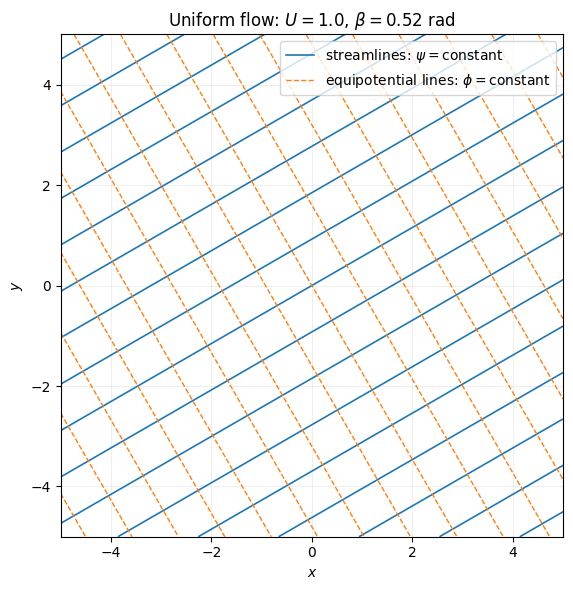

In [2]:
U, beta = 1.0, np.pi/6
x, y = np.linspace(-5, 5, 300), np.linspace(-5, 5, 300)

X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

W_uniform = uniform_complex_potential(Z, U, beta)
phi, psi = W_uniform.real, W_uniform.imag
fig, ax = plot_streamlines_and_equipotentials(X, Y, phi, psi, title=rf"Uniform flow: $U={U}$, $\beta={beta:.2f}$ rad")

We do infact verify that both contours are orthogonal to each other at every point. The streamlines create an angle $\frac{\pi}{6}$ with the x-axis as expected.

### Source and sink
Let $Q \in \mathbb{R}$ be a 'source strength'. Then the corresponding point source potential is given by:
$$
w(z) = \frac{Q}{2\pi} \log{z}
$$
If $Q>0$ then we have a source, and if $Q<0$ it is called a sink. We will justify the naming of this below. We use polar co-ordinates for this derivation, let $z=re^{i\theta}$ for $\theta \in [0, 2\pi), r>0$, then:
$$
w(r, \theta) = \frac{Q}{2\pi} \left(\log{r} + i\theta\right)
$$
Then, recall $w(r, \theta) = \phi(r, \theta) + i\psi(r, \theta)$, so comparing real, imaginary parts we get:
$$
\phi(r, \theta) = \frac{Q}{2\pi} \log{r}, \qquad \psi(r, \theta) = \frac{Q \theta}{2\pi}
$$
Applying polar co-ordinate changes to our relationships between $\phi$, $u, v$ gives:
$$
u = \frac{\partial \phi}{\partial r}, \qquad v = \frac{1}{r}\frac{\partial \phi}{\partial \theta}
$$
giving $\mathbf{u}(r, \theta) = \frac{Q}{2\pi r} \mathbf{e}_r$. In other words, there is no angular component. You may be wondering, why is this called a point source/sink? Lets consider the divergence and curl of $\mathbf{u}$. There is obviously an issue at $r=0$ for any $\theta$, so for $r\neq0$ (using the formula for divergence, curl in polar co-ordinates):
$$
\nabla \cdot \mathbf{u} = \frac{1}{r}\left(\frac{\partial}{\partial r}(ru) + \frac{\partial v}{\partial \theta}\right)= 0
$$
$$
\nabla \times \mathbf{u} = \frac{1}{r}\left(\frac{\partial}{\partial r}(rv) - \frac{\partial u}{\partial \theta}\right)\mathbf{e}_z = \mathbf{0}
$$
This calculation does not tell us anything about the behaviour at $r=0$. To do that, consider a line integral on a circle of small radius $R>0$. Let $B(0, R)$ be the entire circle, and $C(0, R)$ be the boundary. Let $\mathbf{u}$ be the outward pointing unit normal to the circle ($\mathbf{e}_r$), and $\mathbf{t}$ be the tangent vector to the boundary ($\mathbf{e}_\theta$), then:
$$
\int_{C(0, R)} \mathbf{u} \cdot \mathbf{n} \,ds = \int_{0}^{2\pi} \frac{Q}{2\pi r} \mathbf{e}_r \cdot r\mathbf{e}_r \,d\theta = Q
$$
$$ 
\int_{C(0, R)} \mathbf{u} \cdot\mathbf{t} \,ds = \int_{0}^{2\pi} \frac{Q}{2\pi r} \mathbf{e}_r \cdot r\mathbf{e}_\theta \,d\theta = 0
$$
Hence, using the Divergence theorem, then Stokes' theorem on our domain, we get:
$$
\int_{B(0, R)} \nabla \cdot \mathbf{u} \,dA = \int_{C(0, R)} \mathbf{u} \cdot \mathbf{n} \,ds = Q
$$
$$
\int_{B(0, R)} (\nabla \times \mathbf{u}) \cdot \mathbf{e}_z \,dA = \int_{C(0, R)} \mathbf{u} \cdot\mathbf{t} \,ds = 0
$$
Recall that $\nabla \cdot \mathbf{u}=0$ for $r>0$, so the only way this is possible is if $\mathbf{u}$ is 'infinite' at the origin. In mathematical terms, this tells us:
$$
\nabla \cdot \mathbf{u} = Q \delta(\mathbf{r}), \qquad \nabla \times \mathbf{u} = \mathbf{0}
$$
where $\delta(\mathbf{r})$ is the delta-dirac function. Intuitively, this tells us there is a source of mass at the origin. This will be very clear when viewing the streamlines below. Obviously, if $Q=0$ we have no source, and there is no point to what we're doing. We exclude this case.

The equipotential surfaces and streamlines are respectively given by:
$$
\log{r} = \frac{2\pi C_1}{Q}, \qquad \theta = \frac{2\pi C_2}{Q}
$$
These are plotted below.

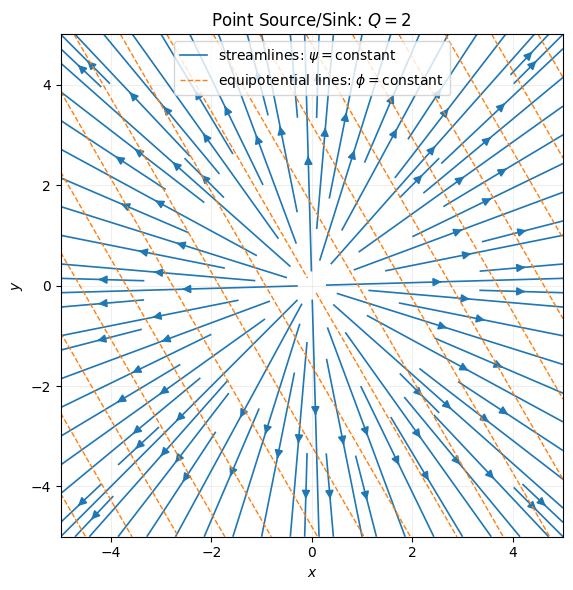

In [3]:
Q = 2
x, y = np.linspace(-5, 5, 300), np.linspace(-5, 5, 300)

X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
Z = np.ma.masked_where(np.abs(Z) < 0.15, Z) #exclude a small region around singularity at z=0
W_source = source_complex_potential(Z, Q)
phi_source, psi_source = W_source.real, W_source.imag

#get arrows for the direction of flow
source_velocity = source_complex_velocity(Z, Q)
u, v = source_velocity.real, -source_velocity.imag

fig, ax = plot_streamlines_and_equipotentials(X, Y, phi, psi, u=u, v=v, title=rf"Point Source/Sink: $Q={Q}$")


See that the streamlines are coming straight from the origin. This is the intuition for why it is called a point source. By swapping the sign of Q, the streamlines act in the opposite direction, making it a sink

### Point vortex

The point vortex acts similarly to the point source. Let $\Gamma \in \mathbb{R}$, this is often called the 'circulation'. Define the following potential:
$$
w(z) = -\frac{i \Gamma}{2\pi} \log{z}
$$
The derivation of this system is near enough identical to the above, so we limit details. Again using polar co-ordinates and comparing real, imaginary:
$$
\phi(r, \theta) =\frac{\Gamma \theta}{2\pi} \qquad \psi(r, \theta) = -\frac{\Gamma}{2\pi} \log{r}
$$
Using the same polar co-ordinate transformations as before and differentiating gives:
$$
\mathbf{u} = \frac{\Gamma}{2\pi r} \mathbf{e}_\theta
$$
Doing the same divergence, curl calculations as above for $r \neq 0$, ($\mathbf{u} = (u,v)$):
$$
\nabla \cdot \mathbf{u} = \frac{1}{r}\left(\frac{\partial}{\partial r}(ru) + \frac{\partial v}{\partial \theta}\right)= 0
$$
$$
\nabla \times \mathbf{u} = \frac{1}{r}\left(\frac{\partial}{\partial r}(rv) - \frac{\partial u}{\partial \theta}\right)\mathbf{e}_z = \mathbf{0}
$$
To know about the origin, consider a circle of small $r>0$ around the origin. Let $B(0,r), C(0,r)$ as before, then:
$$
\int_{C(0, R)} \mathbf{u} \cdot \mathbf{n} \,ds = \int_{0}^{2\pi} \frac{\Gamma}{2\pi r} \mathbf{e}_\theta \cdot r\mathbf{e}_r \,d\theta = 0
$$
$$ 
\int_{C(0, R)} \mathbf{u} \cdot\mathbf{t} \,ds = \int_{0}^{2\pi} \frac{\Gamma}{2\pi r} \mathbf{e}_\theta \cdot r\mathbf{e}_\theta \,d\theta = \Gamma
$$
So, applying the divergence theorem, then Stokes' theorem, we get:
$$
\int_{B(0, R)} \nabla \cdot \mathbf{u} \,dA = \int_{C(0, R)} \mathbf{u} \cdot \mathbf{n} \,ds = 0
$$
$$
\int_{B(0, R)} (\nabla \times \mathbf{u}) \cdot \mathbf{e}_z \,dA = \int_{C(0, R)} \mathbf{u} \cdot\mathbf{t} \,ds = \Gamma
$$
Giving the same 'infinite' effect at the origin as for the point source, but for the $\theta$ component rather than the $r$ component. Mathematically:
$$
\nabla \cdot \mathbf{u} = 0, \qquad \nabla \times \mathbf{u} = \Gamma \delta(\mathbf{r}) \mathbf{e}_z
$$

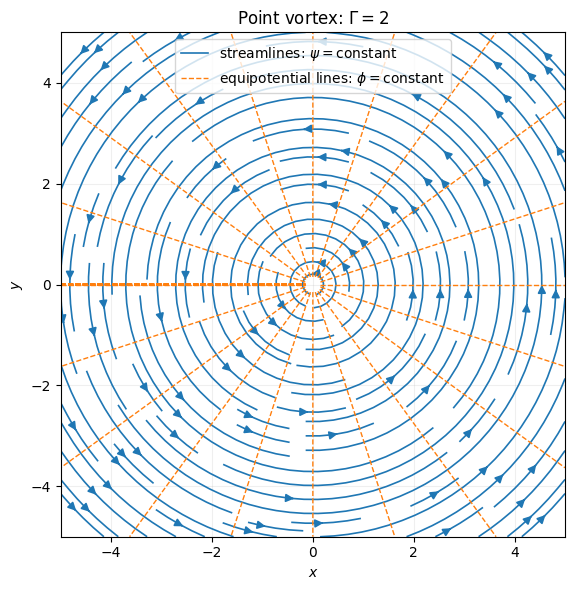

In [4]:
Gamma = 2
x, y = np.linspace(-5, 5, 300), np.linspace(-5, 5, 300)

X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
Z = np.ma.masked_where(np.abs(Z) < 0.15, Z) 
W_vortex = vortex_complex_potential(Z, Gamma)
phi, psi = W_vortex.real, W_vortex.imag

#get arrows for the direction of flow
vortex_velocity = vortex_complex_velocity(Z, Gamma)
u, v = vortex_velocity.real, -vortex_velocity.imag

fig, ax = plot_streamlines_and_equipotentials(X, Y, phi, psi, u=u, v=v, title=rf"Point vortex: $\Gamma={Gamma}$")

As opposed to the point source, the streamlines are now rotating about the origin, as opposed to coming straight from the origin. From the visual, it should be clear as to why this is called a point vortex. Swapping the sign of $\Gamma$, the streamlines travel in the opposite direction. This flow will be very important to us later on when discussing flow around a cylinder.

### Dipole

This potential is derived by taking a limit of a point source and an equal strenght point sink, as they get arbritrarily close to each other. Let $Q$ be the source strength, with a point source at $-a$, and the same strength point sink at $a$. Then, the potential of the system is:
$$
w(z) = \frac{Q}{2\pi}\left(\log{(z + a)} - \log{(z - a)}\right)
$$
As $a \to 0$, this disappears, but let $Q$ be inversely proportional to the distance between them, specfically $Q=\frac{D}{2a}$ where $D\in \mathbb{R}$ is a so called 'dipole strength'. Taking $a \to 0$ in the above:
$$
w(z) = \lim_{a\to 0} \frac{D}{2\pi}\left(\frac{\log{(z + a)} - \log{(z - a)}}{2a}\right) = \frac{D}{2\pi z}
$$
Since the expression inside the brackets is one way of expressing the derivative of log, which is $\frac{1}{z}$. The streamlines for this potential are plotted below.

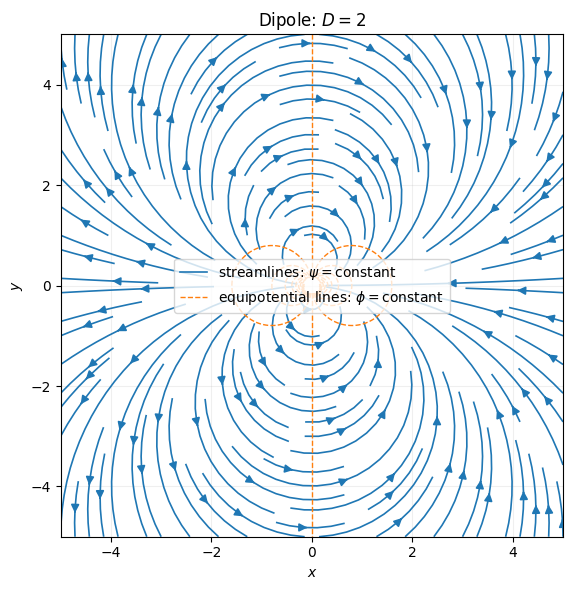

In [5]:
D = 2
x, y = np.linspace(-5, 5, 300), np.linspace(-5, 5, 300)

X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
Z = np.ma.masked_where(np.abs(Z) < 0.15, Z) 
W_dipole = dipole_complex_potential(Z, D)
phi, psi = W_dipole.real, W_dipole.imag

#get arrows for the direction of flow
dipole_velocity = dipole_complex_velocity(Z, D)
u, v = dipole_velocity.real, -dipole_velocity.imag

fig, ax = plot_streamlines_and_equipotentials(X, Y, phi, psi, u=u, v=v, title=rf"Dipole: $D={D}$")

Can see that the streamlines come out of the origin on the left and return to the origin on the right. This is also a very important flow, as we will see.

## **Superposition**


We now discuss adding potential flows together. Let $w_1, w_2$ be complex potentials, then:
$$
w_1(z) + w_2(z) = \phi_1(z) + \phi_2(z) + i\left(\psi_1(z) + \psi_2(z)\right)
$$
Let $w = w_1 + w_2$, then $\text{Re}(w) := \phi = \phi_1 + \phi_2$, $\text{Im}(w) := \psi = \psi_1 + \psi_2$. $w$ is complex differentiable since it is the sum of two complex differentiable functions, and analytic since the Cauchy-Riemann equations are satisfied:
$$
\frac{\partial \phi}{\partial x} = \frac{\partial \phi_1}{\partial x} + \frac{\partial \phi_2}{\partial x} = \frac{\partial \psi_1} {\partial y} + \frac{\partial \psi_2} {\partial y} = \frac{\partial \psi} {\partial y}
$$
$$
\frac{\partial \phi}{\partial y} = \frac{\partial \phi_1}{\partial y} + \frac{\partial \phi_2}{\partial y} = -\frac{\partial \psi_1}{\partial x} - -\frac{\partial \psi_2}{\partial x} =  -\frac{\partial \psi}{\partial x}
$$
$\phi, \psi$ also satisfy Laplace's equation since it is a linear PDE.

We give an example, which is a uniform flow with a point source at the origin, i.e, potential:
$$
w(z) = Uz + \frac{Q}{2\pi}\log{z}
$$
This has complex velocity given by:
$$
w'(z) = U + \frac{Q}{2\pi z}
$$
Here we introduce the concept of a stagnation point. A point $z_s \in \mathbb{C}$ is called a stagnation point of a flow with complex potential $w$ iff $w'(z_s) = 0$. In the above:
$$
0 = w'(z_s) = U + \frac{Q}{2\pi z_s} \implies z_s = \frac{-Q}{2\pi U}
$$
For $Q > 0$ (source, not sink), this lies on the negative x-axis. We get a plot of the streamlines below. 

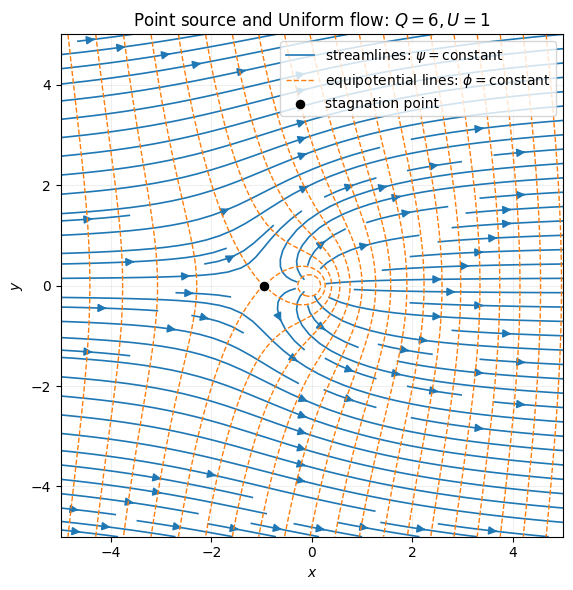

In [6]:
Q, U = 6, 1
x, y = np.linspace(-5, 5, 1000), np.linspace(-5, 5, 1000)

X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
Z = np.ma.masked_where(np.abs(Z) < 0.15, Z) #exclude a small region around singularity at z=0

W = source_complex_potential(Z, Q) + uniform_complex_potential(Z, U, 0)
complex_velocity = source_complex_velocity(Z, Q) + U

phi, psi = W.real, W.imag
u, v = complex_velocity.real, -complex_velocity.imag
z_s = -Q/(2 * np.pi * U)

fig, ax = plot_streamlines_and_equipotentials(X, Y, phi, psi, u=u, v=v, stagnation_points=z_s, title=rf"Point source and Uniform flow: $Q={Q}, U={U}$")

The flow here can be used to define the Rankine half-body, although we do not do this. This idea is very important in our next topic, except its a dipole instead of a point source.

## **Flow around a circular cylinder**


Consider a uniform flow with speed $U$, and a dipole with dipole strength $D$. Then the complex potential of this flow is given by:
$$
w(z) = Uz + \frac{D}{2\pi z}
$$
Our first task is to find the stagnation points. The complex velocity is given by:
$$
w'(z) = U - \frac{D}{2\pi z^2}
$$
Hence, stagnation points must satisfy:
$z^2 = \frac{D}{2\pi U}$. We use the following notation for each stagnation point:
$$
(z_p, z_n) = \left(\sqrt{\frac{D}{2\pi U}}, -\sqrt{\frac{D}{2\pi U}}\right)
$$
Now define $a= \sqrt{\frac{D}{2\pi U}} > 0$. Then our potential becomes:
$$
w(z) = U\left(z + \frac{a^2}{z}\right)
$$
This is the potential for a flow around a cylinder of radius $a$ that you may be familiar with if you have seen this before. We will now show this. Using polar co-ordinates again, gives:
$$
w(r, \theta) = U\left(re^{i\theta} + \frac{a^2}{r} e^{-i\theta}\right)
$$
writing $e^{i\theta} = \cos{\theta} + i\sin{\theta}$ and comparing real, imaginary gives:
$$
\phi(r, \theta) = U\left(r\cos{\theta} + \frac{a^2}{r} \cos{\theta}\right), \qquad \psi(r, \theta) = U\left(r \sin{\theta} - \frac{a^2}{r} \sin{\theta}\right)
$$
At $r=a$, for each $\theta$, $\psi(r, \theta)=0$. Specifically, it is constant, so this is a streamline of our flow. We define this as the boundary of our cylinder, justifying the use of such potential. Using the same polar co-ordinate relationships as before (and slightly abusing notation using $u$ for the r-direction, $v$ for the $\theta$ direction, $\mathbf{u}=(u, v)$):
$$
u = \frac{\partial \phi}{\partial r} = U\cos{\theta}\left(1 - \frac{a^2}{r^2}\right), \qquad v = \frac{1}{r} \frac{\partial \phi}{\partial \theta} = -U\sin{\theta} \left(1 + \frac{a^2}{r^2}\right)
$$
So at $r=a$:
$$
u = 0, \qquad v = -2U\sin{\theta}
$$
This means the two stagnation points occur at $\theta=0, \pi$ on the boundary of the cylinder, identical to what was said when we had just the uniform flow and the dipole, just with different notation. In terms of boundary conditions, on our boundary, $r=a$, which has unit normal $\hat{\mathbf{n}} = \mathbf{e}_r$, our flow satisfies:
$$
\mathbf{u}\cdot\hat{\mathbf{n}} = \mathbf{u}\cdot\mathbf{e}_r = u(r=a, \theta) = 0
$$
and hence no-penetration condition satisfied. As $r\to\infty, u\to U\cos{\theta}, v\to -U\sin{\theta}$. Recall $\mathbf{e}_x = \cos{\theta} \mathbf{e}_r - \sin{\theta} \mathbf{e}_\theta$, hence as $r\to\infty$, $\mathbf{u} \to U\cos{\theta}\mathbf{e}_r  -U\sin{\theta}\mathbf{e}_\theta = U \mathbf{e}_x$, hence the far-field condition is also satisfied.

The surface is plotted below.

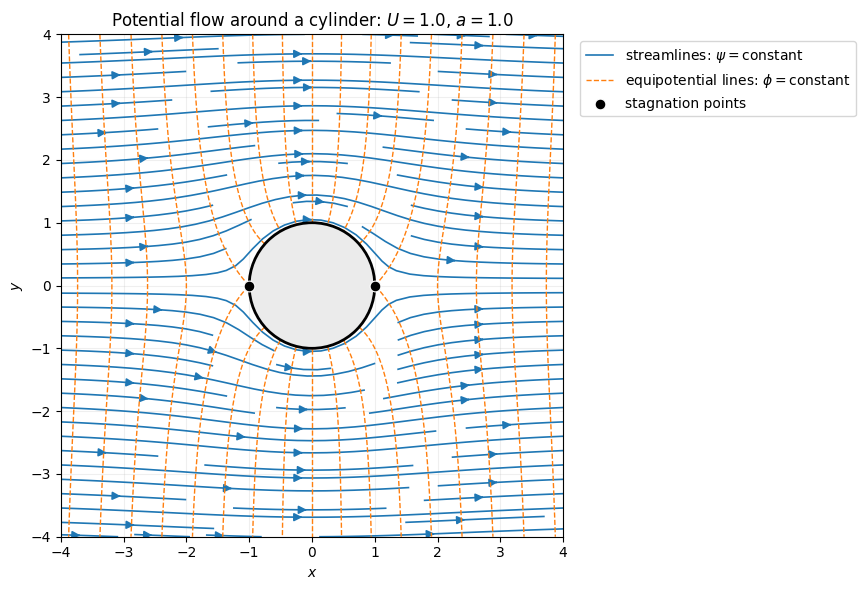

In [7]:
U, a = 1.0, 1.0
fig, ax = plot_cylinder_flow(U=U, a=a)


### ***Bernoulli/Pressure sidenote***

We use Bernoulli's equation for a steady, inviscid flow, which can be derived by projecting the inviscid, incompressible Navier-Stokes equations along a streamline. Bernoulli's equation states, while neglecting gravitational effects:
$$
p + \frac{\rho |\mathbf{u}|^2}{2} = \text{constant along a streamline}
$$
Where $p$ is the pressure of the flow, and $\rho$ is the density of the flow. (strictly, since the flow is potential, it is irrotational and hence this applies anywhere in the fluid domain, not just along a streamline, but this is not necessary here)

We have far-field conditions of $p \to p_\infty, \mathbf{u} \to U\mathbf{e}_x$, so inputting into the above gives:
$$
p - p_\infty = \frac{\rho}{2}\left(U^2 - |\mathbf{u}|^2\right)
$$
Consider the surface of our cylinder, $r=a$, then $u=0, v=-2U\sin{\theta}$, so inputting gives:
$$
p(a, \theta) - p_\infty = \frac{\rho U^2}{2}\left(1 - 4\sin^2{\theta}\right)
$$
The pressure coefficient (on the surface of the cylinder) is defined as:
$$
C_p(\theta) := \frac{p(a, \theta) - p_\infty}{\frac{1}{2}\rho U^2} = 1 - 4\sin^2{\theta}
$$
We get a plot of this coefficient as a function of $\theta$ below:

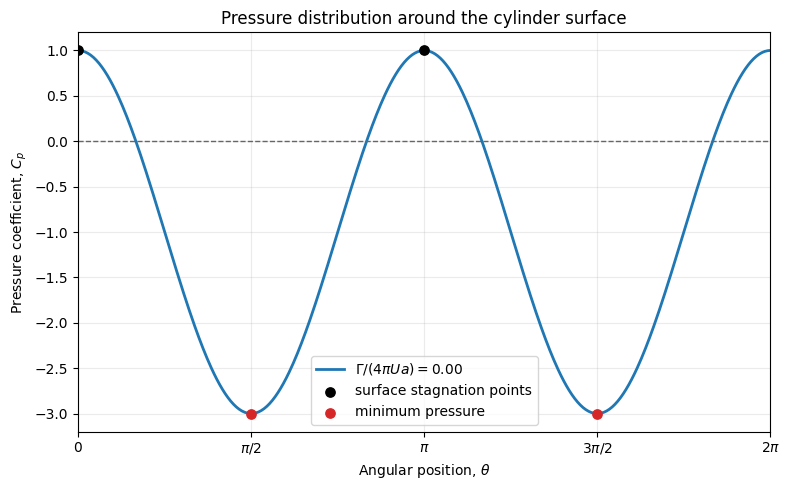

In [8]:
fig, ax = plot_cylinder_pressure_distribution()

Notice that maximum pressure on the surface occurs at the stagnation points, with minimum pressure at the 'top and bottom' of the surface. The pressure on the surface is symmetric across the top and bottom, and across left to right. As a result, there is no pressure gradient acting on the cylinder in either vertical or horizontal directions, and hence no force acting on the surface of the cylinder. The vertical force is called lift, and will be discussed very shortly. The horizontal force is called drag, and it being zero here is something known as d'Alemberts paradox. It is broken by considering a boundary layer near the cylinder, where the flow is viscous. This is not covered in this project.

## **Circulation and lift**


We introduce a circulation $\Gamma$ to the cylinder above using a point vortex at the origin. This can be thought of as a rotating cylinder, whereas the one above had a static (non-rotating) boundary. Using the principle of superposition, the complex potential is given by:
$$
w(z) = U\left(z + \frac{a^2}{z}\right) -\frac{i \Gamma}{2\pi} \log{z}
$$
For this to still be a cylinder, we still need a streamline at $r=a$. Using polar co-ordinates and comparing real, imaginary, we get:
$$
\phi(r, \theta) = U\left(r\cos{\theta} + \frac{a^2}{r} \cos{\theta}\right) + \frac{\Gamma \theta}{2\pi}, \qquad \psi(r, \theta) = U\left(r \sin{\theta} - \frac{a^2}{r}  \sin{\theta}\right) -\frac{\Gamma}{2\pi} \log{r}
$$
So specifically, at $r=a$:
$$
\psi(a, \theta) = -\frac{\Gamma}{2\pi} \log{a}
$$
Which is constant, and hence a streamline for any $\Gamma\in\mathbb{R}$. We can define the surface in the same way as before, so our cylinder of radius $a$ remains. Calculating the velocity using the same polar co-ordinates relationships (and abusing notation for $\mathbf{u} = u\mathbf{e}_r + v\mathbf{e}_\theta$):
$$
u = \frac{\partial \phi}{\partial r} = U\cos{\theta}\left(1 - \frac{a^2}{r^2}\right), \qquad v = \frac{1}{r} \frac{\partial \phi}{\partial \theta} = -U\sin{\theta} \left(1 + \frac{a^2}{r^2}\right) + \frac{\Gamma}{2\pi r}
$$
At a stagnation point, $u=v=0$. Hence either $r=a$, or $\theta = \frac{\pi}{2}, \frac{3\pi}{2}. This gives one condition for stagnation points on the surface of the cylinder, and one condition elsewhere in the flow. We only concern ourselves with the stagnation points on the surface, so enforce $r=a$. Solving for the corresponding $\theta$:
$$
0 = -2U\sin{\theta} + \frac{\Gamma}{2\pi a} \implies \sin{\theta} = {\frac{\Gamma}{4\pi U a}}
$$
If $|\Gamma| > 4 \pi U a$, then this stagnation point does not exist. Assuming $|\Gamma| \leq 4 \pi U a$ This gives two options for for $\theta$, namely:
$$
\theta_1 = \sin^{-1} \left({\frac{\Gamma}{4\pi U a}}\right), \qquad \theta_2 = \pi - \theta_1
$$
If $\Gamma=0$, then this reduces to the original cylinder's stagnation points, else, they move more towards the 'top' or 'bottom' of the cylinder, depending on the sign of $\Gamma$.

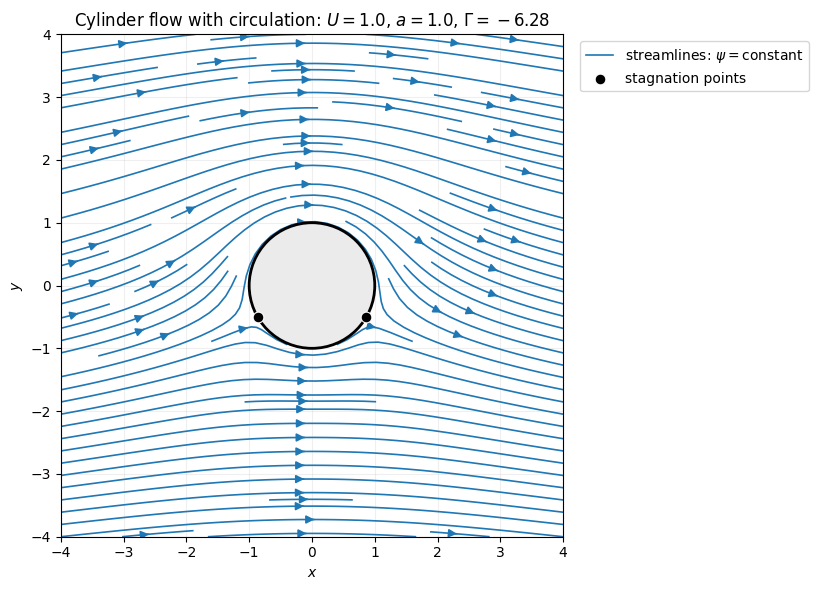

In [9]:
U, a = 1.0, 1.0
circulation_ratio = - 0.5 #change sign to reverse direction of circulation
Gamma = circulation_ratio * 4 * np.pi * U * a

fig, ax = plot_circulating_cylinder_flow(U=U, a=a, Gamma=Gamma)


If the circulation is negative, the cylinder seems to rise, and vice versa. We again use Bernoulli to derive this relationship. Recall:
$$
p - p_\infty = \frac{\rho}{2}\left(U^2 - |\mathbf{u}|^2\right)
$$
On the surface, $r=a$, so $|\mathbf{u}|^2$ is given by:
$$
|\mathbf{u}|^2 = \left(-2U \sin{\theta} + \frac{\Gamma}{2\pi a}\right)^2 = 4U^2 \sin^2{\theta} - \frac{2U \Gamma \sin{\theta}}{\pi a} + \frac{\Gamma^2}{4\pi^2 a^2}
$$
Then, inputting this into Bernoulli gives:
$$
p - p_\infty = \frac{\rho}{2} \left(U^2 - 4U^2 \sin^2{\theta} + \frac{2U \Gamma \sin{\theta}}{\pi a} - \frac{\Gamma^2}{4\pi^2 a^2}\right)
$$
Dividing through by $\frac{1}{2} \rho U^2$, and recalling the definition of the pressure coefficient, we get:
$$
C_p(\theta) = 1 - 4 \sin^2{\theta} + \frac{2 \Gamma \sin{\theta}}{\pi U a} - \left(\frac{\Gamma}{2 \pi a U}\right)^2 = 1 - \left(\frac{\Gamma}{2 \pi a U} -2\sin{\theta}\right)^2
$$
This plot is shown below.

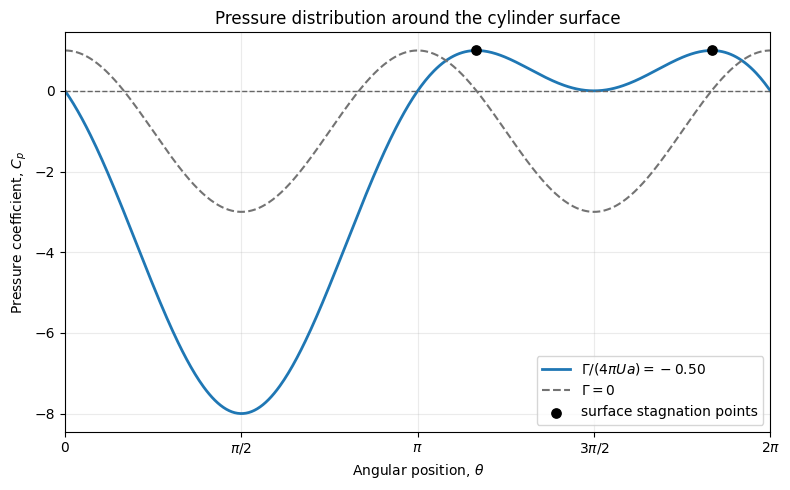

In [10]:
fig, ax = plot_cylinder_pressure_distribution(U=U, a=a, Gamma=Gamma, compare_zero_circulation=True)


Again, as expected, stagnation points experience maximum pressure. There is also a pressure minimum at $\frac{\pi}{2}$, which intuitively means that there is a pressure gradient 'upwards'. We will derive this momentarily. If the sign of $\Gamma$ is swapped, then all directions are reversed, and the point of minimum pressure is $\frac{3\pi}{2}$, i.e, the downwards not upwards.

A negative pressure gradient is one thing that can drive a force. Specifically, $- \nabla p$ is the force per unit volume acting on a fluid element. Seperately, pressure produces a surface force per unit area given by $-p\hat{\mathbf{n}}$, where $\hat{\mathbf{n}}$ is the outward pointing unit normal to the surface. These two concepts are connected by the Divergence theorem. In order words, $d\mathbf{F} = -p\hat{\mathbf{n}}\,dS$

On our cylinder, $\hat{\mathbf{n}}$ = $\cos{\theta}\mathbf{e}_x + \sin{\theta} \mathbf{e}_y$, and for a cylinder with unit length, $dS = a\,d\theta$. Placing into cartesian co-ordinates, we get:
$$
dF_x = -p a \cos{\theta}\, d\theta
$$
$$
dF_y = -p a \sin{\theta}\, d\theta
$$
The horizontal force is often referred to as 'drag', with the vertical force often being call 'lift'. Integrating over the loop, we get:
$$
D = -a \int_{0}^{2\pi} p(a, \theta) \cos{\theta}\, d\theta
$$
$$
L = -a \int_{0}^{2\pi} p(a, \theta) \sin{\theta}\, d\theta
$$
$p_\infty$ can be ignored, since integrating $\cos, \sin$ over $[0, 2\pi]$ gives zero, hence $\int_{0}^{2\pi} p_\infty \cos{\theta}\, d\theta$ = $\int_{0}^{2\pi} p_\infty \sin{\theta}\, d\theta$ = 0. So we are left with:
$$
D = \frac{-a \rho}{2} \int_{0}^{2\pi} (U^2 - |\mathbf{u}(a, \theta)|^2)  \cos{\theta}\, d\theta
$$
$$
L = \frac{-a \rho}{2} \int_{0}^{2\pi} (U^2 - |\mathbf{u}(a, \theta)|^2) \sin{\theta}\, d\theta
$$
Hence, inputting the result for $|\mathbf{u}(a, \theta)|^2$:
$$
D = \frac{-a \rho}{2} \int_{0}^{2\pi} \left(U^2 - 4U^2 \sin^2{\theta} + \frac{2U \Gamma \sin{\theta}}{\pi a} - \frac{\Gamma^2}{4\pi^2 a^2}\right)  \cos{\theta}\, d\theta
$$
$$
L = \frac{-a \rho}{2} \int_{0}^{2\pi} \left(U^2 - 4U^2 \sin^2{\theta} + \frac{2U \Gamma \sin{\theta}}{\pi a} - \frac{\Gamma^2}{4\pi^2 a^2}\right) \sin{\theta}\, d\theta
$$


Notice $\int_{0}^{2\pi}  \sin^3{\theta}\, d\theta$ =$\int_{0}^{2\pi}   \sin{\theta}\cos{\theta}\, d\theta$ =$\int_{0}^{2\pi}   \sin^2{\theta}\cos{\theta}\, d\theta$ =  0, and $\int_{0}^{2\pi}  \sin^2{\theta}\, d\theta = \pi$, alongside the cos, sin relations. This gives:

$$
D = \frac{-a \rho}{2} \int_{0}^{2\pi} \left(U^2 - 4U^2 \sin^2{\theta} + \frac{2U \Gamma \sin{\theta}}{\pi a} - \frac{\Gamma^2}{4\pi^2 a^2}\right)  \cos{\theta}\, d\theta = 0
$$
$$
L = \frac{-a \rho}{2} \int_{0}^{2\pi} \left(U^2 - 4U^2 \sin^2{\theta} + \frac{2U \Gamma \sin{\theta}}{\pi a} - \frac{\Gamma^2}{4\pi^2 a^2}\right) \sin{\theta}\, d\theta = \frac{-a \rho}{2} \frac{2 U \Gamma \pi}{\pi a} = -\rho U \Gamma
$$
This is the important lift result which causes the Magnus effect:
$$
\boxed{L = -\rho U \Gamma}
$$
We see that the direction is dependent on the sign of $\Gamma$, that if $\Gamma <0$, then the cylinder travels upwards, and $\Gamma > 0$ gives a downward motion. This aligns with the intuition for the pressure plot.

## **Passive tracers and render**


We end with a visual of what has just been shown, that is the lift caused by the point vortex. This render is created by solving:

$$
\dot{x}=u(x,y), \qquad \dot{y}=v(x,y)
$$


In [ ]:
animation, fig, ax = render_lifting_cylinder(U=2.0, a=3.0, Gamma=-2 * np.pi, rho=1.0, cylinder_mass_per_length=20 * np.pi, duration=10.0,
    fps=30, angular_speed=-2 * np.pi / 3, include_added_mass=False, output_path="media/lifting_cylinder.gif")

![Render of cylinder lift](media/lifting_cylinder.gif)

There is also an .mp4 in the media folder, which is higher quality.